In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask.array as da
import os

import json
import torch  

import torch
import deepsensor.torch
import sys 
from deepsensor.data import DataProcessor, TaskLoader, construct_circ_time_ds
from deepsensor.model.nps import construct_neural_process
from deepsensor.model import ConvNP
from deepsensor.train import Trainer, set_gpu_default_device

# Local package utilities
from deepsensor_greatlakes.utils import standardize_dates, generate_random_coordinates, generate_random_coordinates_seed
from deepsensor_greatlakes.model import save_model, load_convnp_model

In [2]:
# Path to the files on U-M HPC
bathymetry_path = '/nfs/turbo/seas-dannes/SST-sensor-placement-input/bathymetry/interpolated_bathymetry.nc'
mask_path = '/nfs/turbo/seas-dannes/SST-sensor-placement-input/masks/lakemask.nc'
ice_concentration_path = '/nfs/turbo/seas-dannes/SST-sensor-placement-input/ice_concentration_processed.zarr'
glsea_path = '/nfs/turbo/seas-dannes/SST-sensor-placement-input/glsea_anom_processed.zarr'
#glsea_path = '/nfs/turbo/seas-dannes/SST-sensor-placement-input/GLSEA_combined.zarr'
glsea_raw_path = '/nfs/turbo/seas-dannes/SST-sensor-placement-input/GLSEA3_combined.zarr'

In [3]:
# Paths to saved configurations
deepsensor_folder = '../deepsensor_config/'

data_processor = DataProcessor(os.path.join(deepsensor_folder, "data_processor"))

#model_name =  "full_data_ice_11_4"
model_name = "anoms_ice_11_12"
output_dir = "../../models/"

In [4]:
# Open the Zarr stores
ice_concentration = xr.open_zarr(ice_concentration_path)
glsea = xr.open_zarr(glsea_path)
glsea_raw = xr.open_zarr(glsea_raw_path)

# Replace -1 (land value) with NaN
ice_concentration = ice_concentration.where(ice_concentration != -1, float('nan'))

# Convert all times to date-only format, removing the time component
ice_concentration = standardize_dates(ice_concentration)
glsea = standardize_dates(glsea)
glsea_raw = standardize_dates(glsea_raw)
#glsea3 = standardize_dates(glsea3


# Open the NetCDF files using xarray 
bathymetry_raw = xr.open_dataset(bathymetry_path)
lakemask_raw = xr.open_dataset(mask_path)


# process the bathymetry and lake
bathymetry, lakemask = data_processor([bathymetry_raw, lakemask_raw], method="min_max")


dates = pd.date_range(glsea.time.values.min(), glsea.time.values.max(), freq="D")
dates = pd.to_datetime(dates).normalize()  # This will set all times to 00:00:00

doy_ds = construct_circ_time_ds(dates, freq="D")
cos_D = standardize_dates(doy_ds["cos_D"])
sin_D = standardize_dates(doy_ds["sin_D"])


# Make auxiliary context dataset
aux_ds = xr.Dataset({
    "lakemask": lakemask["mask"],
    "bathymetry": bathymetry["bathymetry"],
    "cos_D": cos_D,
    "sin_D": sin_D,
})

In [5]:
set_gpu_default_device()

In [6]:
# Initialize task loader
task_loader = TaskLoader(
    context = [glsea, ice_concentration, aux_ds],
    target = glsea,
)

In [7]:
ice_model = load_convnp_model(output_dir + model_name + "_model/", data_processor, task_loader)

Attempting to instantiate ConvNP model (randomly initialized initially):
Architectural config for construct_neural_process (passed as **kwargs): {'dim_x': 2, 'dim_yc': [1, 1, 4], 'dim_yt': 1, 'dim_aux_t': 0, 'dim_lv': 0, 'conv_arch': 'unet', 'unet_channels': [64, 64, 64, 64], 'unet_resize_convs': True, 'unet_resize_conv_interp_method': 'bilinear', 'aux_t_mlp_layers': None, 'likelihood': 'het', 'unet_kernels': 5, 'internal_density': 1540, 'encoder_scales': [0.00042372880852781236, 0.00042372880852781236, 0.0003246753185521811], 'encoder_scales_learnable': False, 'decoder_scale': 0.0006493506493506494, 'decoder_scale_learnable': False, 'num_basis_functions': 64, 'epsilon': 0.01}


In [23]:
learn_range = ["2021-01-05", "2022-06-01"]
learn_dates = pd.date_range(learn_range[0], learn_range[1])[::10]

In [9]:
ice_model.data_processor.config

{'coords': {'time': {'name': 'time'},
  'x1': {'name': 'lat', 'map': (38.8749871947229, 55.4132976408956)},
  'x2': {'name': 'lon', 'map': (-92.4199507342304, -75.8816402880577)}},
 'sst_anom': {'method': 'mean_std',
  'params': {'mean': 3.6779758829652565e-06, 'std': 2.022264242172241}},
 'ice_concentration': {'method': 'min_max',
  'params': {'min': 0.0, 'max': 1.0}},
 'bathymetry': {'method': 'min_max',
  'params': {'min': 9.999999999999998, 'max': 316.62872313037894}},
 'mask': {'method': 'min_max', 'params': {'min': 0.0, 'max': 1.0}}}

In [10]:
glsea_anom = data_processor.unnormalise(glsea)

In [11]:
# Configure to match X_s grid later
ice_model.data_processor.config["coords"]["x1"]["name"] = "x1"
ice_model.data_processor.config["coords"]["x2"]["name"] = "x2"

glsea_ds = glsea_anom.sel(time=learn_dates).rename({'lat': 'x1', 'lon': 'x2'})
mask = lakemask_raw['mask'].rename({'lat': 'x1', 'lon': 'x2'})
print(mask)
sst_anom = glsea_ds['sst_anom'].transpose('x1', 'x2', 'time')

<xarray.DataArray 'mask' (x1: 838, x2: 1181)> Size: 4MB
[989678 values with dtype=float32]
Coordinates:
  * x2       (x2) float64 9kB -92.42 -92.41 -92.39 ... -75.91 -75.9 -75.88
  * x1       (x1) float64 7kB 38.87 38.89 38.9 38.92 ... 50.56 50.58 50.59 50.61
Attributes:
    standard_name:  binary land mask
    grid_mapping:   crs


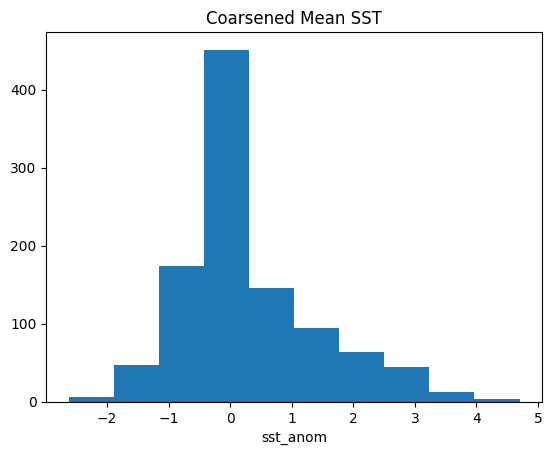

In [45]:
coarse = glsea_ds.coarsen(x1=44, x2=35, boundary="trim").mean()
coarse["sst_anom"].plot()
plt.title("Coarsened Mean SST")
plt.show()

In [24]:
from deepsensor.active_learning import GreedyAlgorithm

greedy_alg = GreedyAlgorithm(
    model=ice_model,
    X_t=glsea_ds ,                 # targets grid (e.g., your SST field)
    X_s=glsea_ds.coarsen(x1=45, x2=35, boundary="trim").mean(),  # coarse search grid
    X_s_mask=mask,           # e.g., land/water or lake mask
    X_t_mask=mask,
    N_new_context=25,
    progress_bar=True,
)

In [52]:
alg_anom = GreedyAlgorithm(
    model=ice_model,
    X_s=glsea_ds,
    X_t=glsea_ds,
    X_s_mask=mask,
    X_t_mask=mask,
    proposed_infill=None,
    N_new_context=5,
    progress_bar=True,
    verbose=True,
)

In [58]:
mg = alg_anom.X_s['sst_anom'].transpose('x1', 'x2', 'time')
proposed_infill = mg.copy(deep = True)

In [59]:
infill_alg = GreedyAlgorithm(
    model=ice_model,
    X_s=glsea_ds,
    X_t=glsea_ds,
    X_s_mask=mask,
    X_t_mask=mask,
    proposed_infill=proposed_infill,
    N_new_context=10,
    progress_bar=True,
    verbose=True,
)

In [60]:
infill_alg.X_s['sst_anom']

<xarray.DataArray 'sst_anom' (time: 6, x1: 838, x2: 1181)> Size: 24MB
dask.array<getitem, shape=(6, 838, 1181), dtype=float32, chunksize=(6, 53, 74), chunktype=numpy.ndarray>
Coordinates:
    month    (time) int64 48B dask.array<chunksize=(6,), meta=np.ndarray>
  * time     (time) datetime64[s] 48B 2022-01-01 2022-01-11 ... 2022-02-20
  * x1       (x1) float64 7kB 0.0 0.0008475 0.001695 ... 0.7076 0.7085 0.7093
  * x2       (x2) float64 9kB 0.0 0.0008475 0.001695 ... 0.9983 0.9992 1.0

In [13]:
lakemask_raw_norm = lakemask_raw
lakemask_raw_norm['mask'] = lakemask_raw_norm['mask'].rename({'lat': 'x1', 'lon': 'x2'})

In [25]:
from deepsensor.active_learning.acquisition_fns import Stddev
acq = Stddev(ice_model)

# Subsample validation dates to average over multiple days without going crazy on compute:
dates = learn_dates[::10]  # e.g., every 10th day
random_lake_points = generate_random_coordinates_seed(lakemask_raw_norm, 250, 0, data_processor)
tasks = task_loader(dates, context_sampling=random_lake_points)

In [26]:
X_new_df, acq_ds = greedy_alg(acq, tasks)

100%|██████████| 150/150 [00:54<00:00,  2.75it/s]


In [29]:
def plot_new_sensor_locs(ds, mask, data_processor, lakemask_raw):    
    latitudes = ds['x1'].values
    longitudes = ds['x2'].values
    
    coord_pairs = np.column_stack((latitudes, longitudes))
    df_coords = pd.DataFrame(coord_pairs, columns=['lat', 'lon'])
    df_unique = df_coords.drop_duplicates().dropna()
    
    df_unique = df_unique.sort_values(by=["lat", "lon"]).reset_index(drop=True)
    
    print(f"Found {len(df_unique)} unique buoy locations.")
    print(df_unique.head())
    df_unique = df_unique.rename(columns={'lat': 'x1', 'lon': 'x2'})
    buoy_da = xr.Dataset(coords={'x1': (['points'], df_unique['x1']),
                                 'x2': (['points'], df_unique['x2'])})
    
    interpolated_mask = mask.interp(x1=buoy_da['x1'], x2=buoy_da['x2'])
    on_lake = interpolated_mask.values == 1
    df_unique = df_unique[on_lake].reset_index(drop=True)
    
    print(f"{len(df_unique)} buoys remain after filtering to valid lakemask points.")
    
    df = df_unique.copy()
    df['dummy'] = 0  # Add dummy column
    df = df.set_index(['x1', 'x2'])
    
    X_c_normalized = data_processor(df, method="min_max").index.to_frame(index=False).values.T
    
    
    #plotting our buoys
    lats = df_unique['x1'].values
    lons = df_unique['x2'].values
    
    crs = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(15, 8), subplot_kw=dict(projection=crs))
    
    lakemask_raw['mask'].plot(ax=ax, transform=crs, cmap='Blues', alpha=0.3)
    ax.scatter(
        lons, lats,
        transform=crs,
        color='red',
        s=50,
        marker='x',
        label='Buoy locations'
    )
    
    ax.coastlines(resolution='10m')
    ax.set_title("Proposed New Buoy Locations")
    ax.legend()
    plt.savefig("buoys.png", dpi = 150)
    plt.show()

Found 25 unique buoy locations.
         lat        lon
0  41.706122 -87.276256
1  41.706122 -81.389739
2  42.336820 -82.861368
3  42.967518 -86.295170
4  43.598217 -86.785713
20 buoys remain after filtering to valid lakemask points.


/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend wi

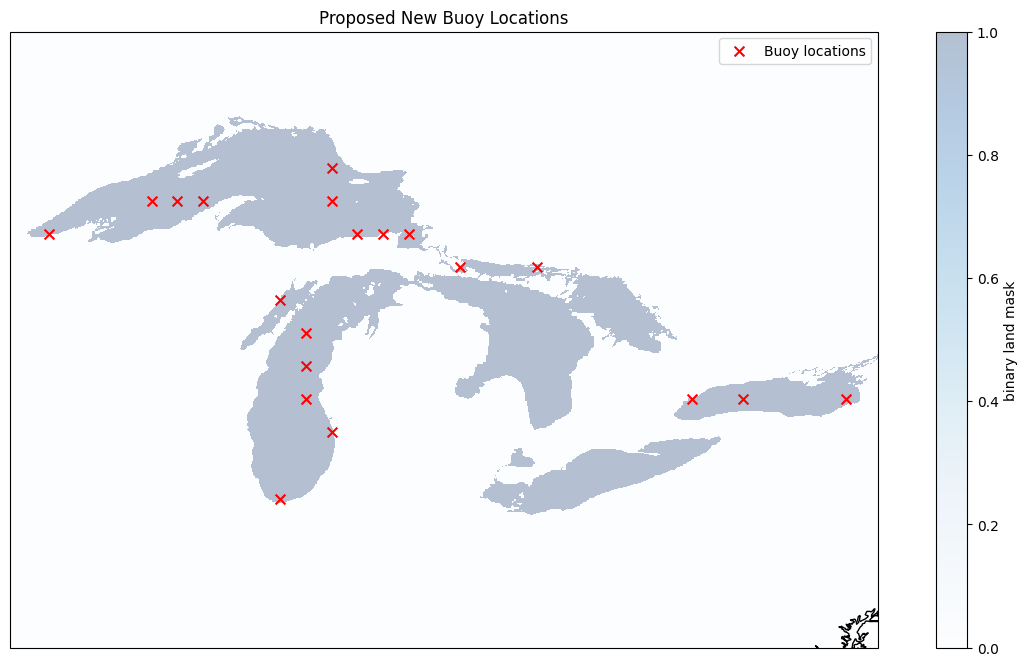

In [30]:
plot_new_sensor_locs(X_new_df, mask, data_processor, lakemask_raw)

In [28]:
from deepsensor.active_learning.acquisition_fns import ContextDist

acquisition_fn = ContextDist(context_set_idx=0)
context_dist_locs, context_acq = greedy_alg(acquisition_fn, tasks[0])

100%|██████████| 10/10 [00:00<00:00, 211.06it/s]


In [20]:
context_dist_locs

,x1,x2
iteration,,
0,49.905199,-76.715564
1,39.183329,-92.160664
2,39.183329,-76.182974


In [38]:
X_new_df

,x1,x2
iteration,,
0,43.598217,-78.845922
1,44.228915,-76.182974
2,46.121010,-82.574050


Found 3 unique buoy locations.
         lat        lon
0  39.183329 -92.160664
1  39.183329 -76.182974
2  49.905199 -76.715564
0 buoys remain after filtering to valid lakemask points.


/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:498: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


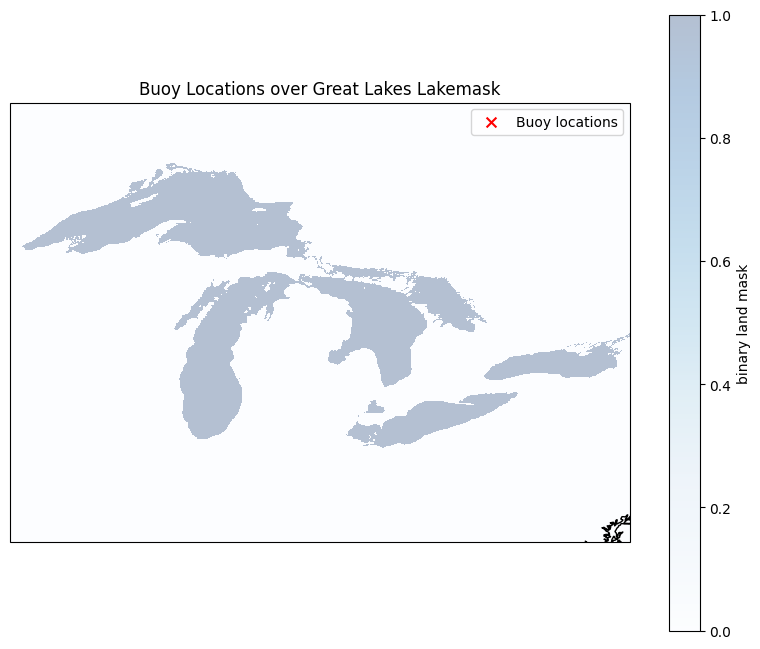

In [21]:
plot_new_sensor_locs(context_dist_locs, mask, data_processor, lakemask_raw)

In [40]:
from deepsensor.active_learning.acquisition_fns import Random

acquisition_fn = Random()
random_locs, random_acq = greedy_alg(acquisition_fn, tasks[0])

100%|██████████| 3/3 [00:00<00:00, 245.65it/s]


Found 3 unique buoy locations.
         lat        lon
0  42.336820 -87.367357
1  42.336820 -79.911102
2  43.598217 -78.845922
2 buoys remain after filtering to valid lakemask points.


/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:498: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/saiavu/deepsensor_sai/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating le

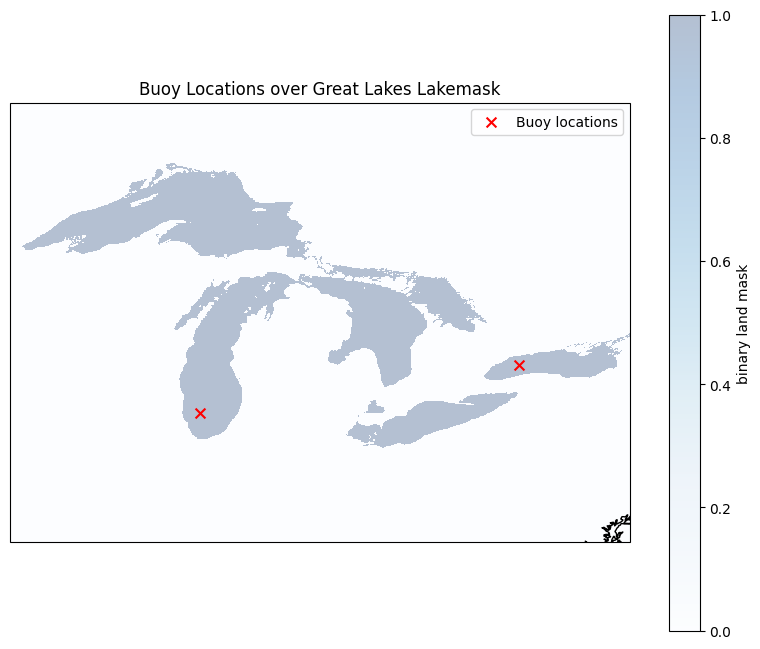

In [41]:
plot_new_sensor_locs(random_locs, mask, data_processor, lakemask_raw)

In [ ]:
from tqdm import tqdm

ice_model.data_processor.config["coords"]["x1"]["name"] = "x1"
ice_model.data_processor.config["coords"]["x2"]["name"] = "x2"


acquisition_fn = Stddev(ice_model)


X_base = X_c_normalized.copy()


truth = glsea_ds['sst_anom'].sel(time=learn_dates)
gbw = mask / mask.sum()

rmses, avgstds, nlls = [], [], []
pred_means, pred_stds = [], []

N_iters = 10

# Overwritten Active Learning Loop to show RMSE by iteration 
for i in tqdm(range(N_iters + 1), desc="Active Learning Loop"):
    placement_tasks = task_loader(
        learn_dates,
        context_sampling=[X_base, "all", "all"],
        target_sampling="all"
    )

    ice_model.data_processor.config["coords"]["x1"]["name"] = "lat"
    ice_model.data_processor.config["coords"]["x2"]["name"] = "lon"
    X_t_array = proposed_infill.sel(time=learn_dates).rename({'x1': 'lat', 'x2': 'lon'})
    X_t_array = X_t_array.assign_coords(lat=X_t_array['lat'], lon=X_t_array['lon'])
    X_t_grid = xr.Dataset({'sst_anom': X_t_array})
    print(X_t_grid)
    pred = ice_model.predict(placement_tasks, X_t=X_t_grid)
    mean_da = pred["sst_anom"]["mean"]
    std_da = pred["sst_anom"]["std"]
    pred_means.append(mean_da)
    pred_stds.append(std_da)

    err = mean_da - truth
    rmse = np.sqrt((err**2).weighted(gbw).mean()).values.item()
    avgstd = std_da.weighted(gbw).mean().values.item()

    std_da_safe = std_da.where(std_da > 1e-6, 1e-6)
    nll = (
        0.5 * np.log(2 * np.pi * std_da_safe ** 2) +
        0.5 * ((truth - mean_da) ** 2) / (std_da_safe ** 2)
    ).weighted(gbw).mean().values.item()

    rmses.append(rmse)
    avgstds.append(avgstd)
    nlls.append(nll)

    if i == N_iters:
        break

    X_new_df, _ = alg(acquisition_fn, placement_tasks)
    x1, x2 = X_new_df.iloc[0][["x1", "x2"]]

    df_new = pd.DataFrame({'x1': [x1], 'x2': [x2], 'dummy': [0]}).set_index(['x1', 'x2'])
    X_new_norm = data_processor(df_new, method="min_max").index.to_frame(index=False).values.T
    X_base = np.concatenate((X_base, X_new_norm), axis=1)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(range(N_iters + 1), rmses, label='RMSE')
axs[0].set_title("RMSE over Iterations")
axs[0].set_xlabel("Iteration")
axs[0].set_ylabel("RMSE")
axs[0].legend()

axs[1].plot(range(N_iters + 1), avgstds, label='Avg. Stddev', color='orange')
axs[1].set_title("Average Stddev over Iterations")
axs[1].set_xlabel("Iteration")
axs[1].set_ylabel("Stddev")
axs[1].legend()

axs[2].plot(range(N_iters + 1), nlls, label='NLL', color='green')
axs[2].set_title("Negative Log Likelihood over Iterations")
axs[2].set_xlabel("Iteration")
axs[2].set_ylabel("NLL")
axs[2].legend()

plt.tight_layout()
plt.show()